In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
%matplotlib inline
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("makeup_sales.csv")
df.head(3)

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64


In [3]:
print("Shape:",df.shape)
print("\ncolumns : ",df.columns)
print("\nData types:",df.dtypes)     

Shape: (500, 10)

columns :  Index(['Sale_ID', 'Date', 'Brand', 'Product_Type', 'Country', 'Sales_Channel',
       'Payment_Method', 'Price_USD', 'Units_Sold', 'Revenue_USD'],
      dtype='object')

Data types: Sale_ID             int64
Date               object
Brand              object
Product_Type       object
Country            object
Sales_Channel      object
Payment_Method     object
Price_USD         float64
Units_Sold          int64
Revenue_USD       float64
dtype: object


In [4]:
df["Date"]=pd.to_datetime(df["Date"])

In [5]:
df.dtypes

Sale_ID                    int64
Date              datetime64[ns]
Brand                     object
Product_Type              object
Country                   object
Sales_Channel             object
Payment_Method            object
Price_USD                float64
Units_Sold                 int64
Revenue_USD              float64
dtype: object

## CLEANING THE DATA

In [6]:
df.isna().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## CALCULATE TOTAL REVENUE

In [8]:
df.head(2)

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.4
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.7


## DISPLAY TOP 5 HIGHEST REVENUE SALES

In [9]:
df.sort_values("Revenue_USD",ascending=False).head(5)

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
389,390,2025-09-10,Huda Beauty,Eyeliner,Saudi Arabia,Online,Card,119.75,50,5987.50
77,78,2025-11-07,L'Oreal,Mascara,India,Online,Digital Wallet,115.83,46,5328.18
236,237,2025-06-17,Dior,Eyeliner,Saudi Arabia,Beauty Salon,Digital Wallet,112.38,47,5281.86
387,388,2025-08-27,Fenty Beauty,Concealer,UK,Beauty Salon,Cash,104.59,50,5229.50
50,51,2025-05-23,Fenty Beauty,Concealer,Germany,Mall,Cash,104.40,50,5220.00


## REVENUE BY BRAND
- calculate total revenue by brand

In [10]:
df.groupby("Brand")["Revenue_USD"].sum().sort_values(ascending=False)

Brand
MAC             155245.81
L'Oreal         123593.20
Dior             99810.99
Fenty Beauty     95001.67
NARS             88792.62
Estee Lauder     86983.48
Huda Beauty      76357.17
Maybelline       67403.56
Name: Revenue_USD, dtype: float64

## MOST SOLD PRODUCT TYPE

In [11]:
df.head(2)

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.4
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.7


In [12]:
df.groupby("Product_Type")["Units_Sold"].sum().sort_values(ascending=False)

Product_Type
Mascara        1900
Eyeshadow      1716
Eyeliner       1646
Lipstick       1592
Highlighter    1526
Foundation     1523
Blush          1453
Concealer      1352
Name: Units_Sold, dtype: int64

In [13]:
ind=df.groupby("Product_Type")["Units_Sold"].sum().sort_values(ascending=False).index

In [14]:
val=df.groupby("Product_Type")["Units_Sold"].sum().sort_values(ascending=False).values

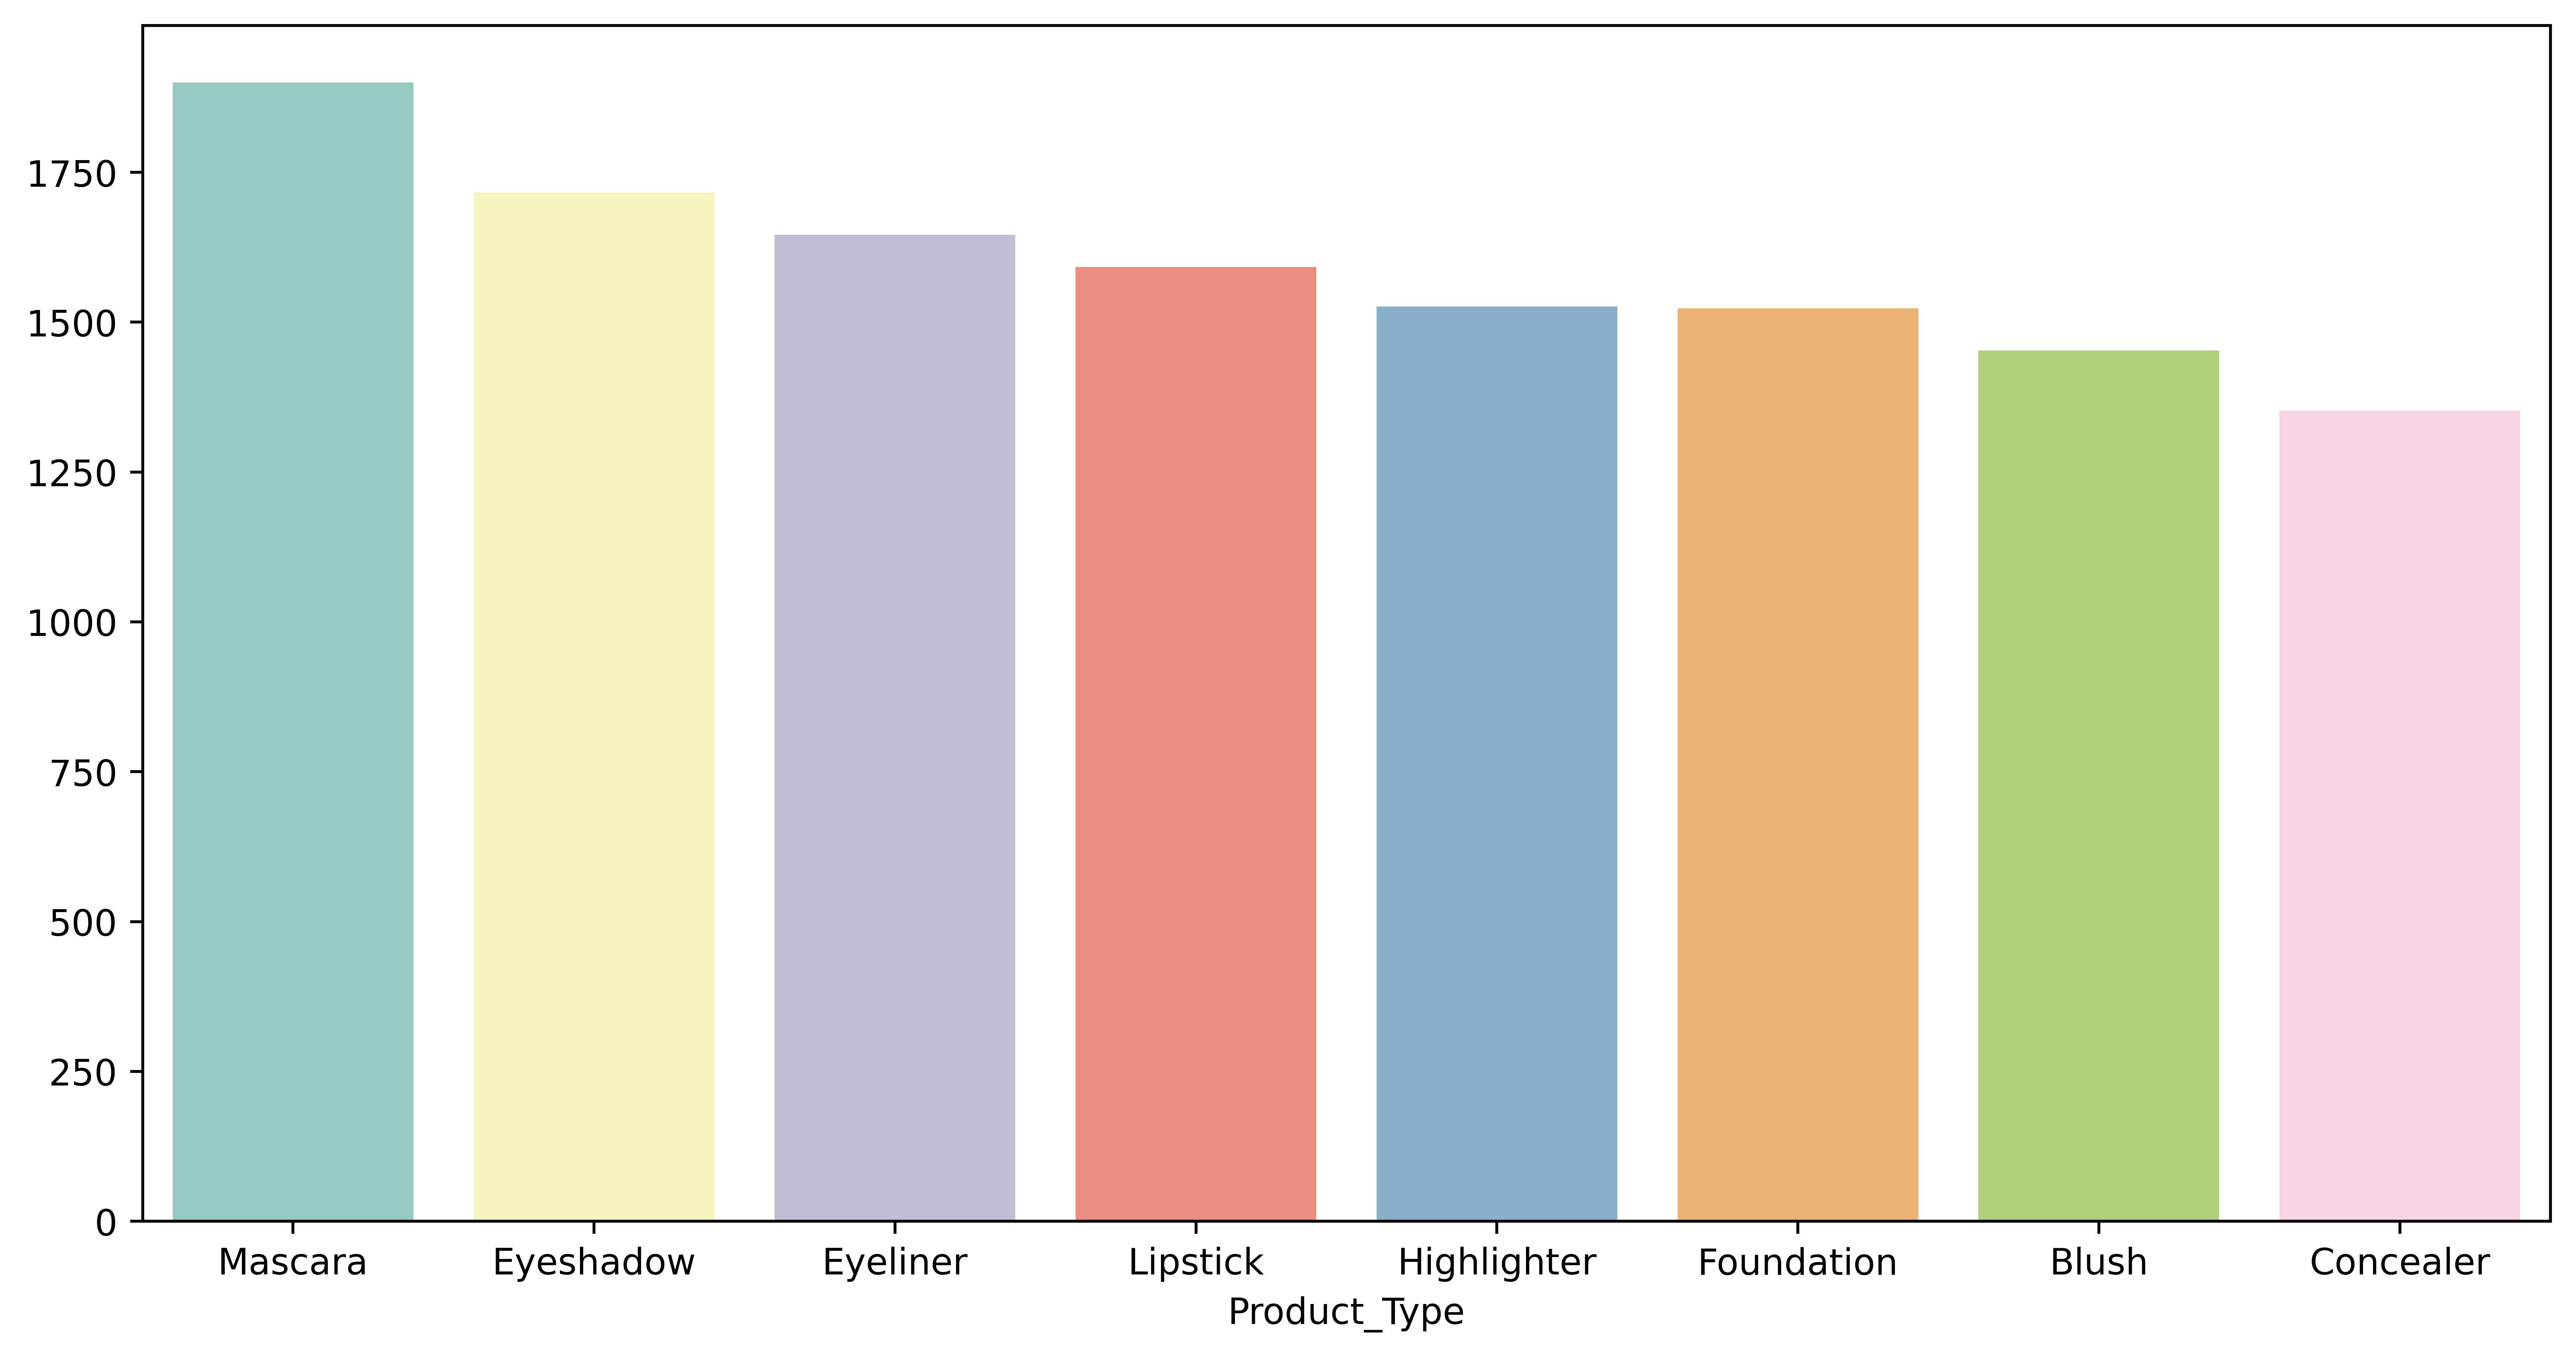

In [15]:
plt.figure(figsize=(12,6),dpi=700)
sns.barplot(x=ind,y=val,palette="Set3")
plt.show()